In [522]:
import pandas as pd
import glob
import re
import matplotlib.pyplot as plt
import os

In [523]:
base_dir_flink = "latency_output/20260421_145433_q11"

files_flink = []

for root, dirs, filenames in os.walk(base_dir_flink):
    for name in filenames:
        if "part-" in name:   # Spark files are usually part-00000...
            files_flink.append(os.path.join(root, name))

print("Found files:", len(files_flink))
for f in files_flink[:10]:
    print(f)

Found files: 9
latency_output/20260421_145433_q11/2026-04-21--15/.part-f95cc62c-4556-4870-99ed-1221984c34d9-1.inprogress.84c0dc67-7847-40b2-a39d-a0976782075c
latency_output/20260421_145433_q11/2026-04-21--15/.part-b1fad0e9-3efa-4a1c-acd3-27c80265a5b0-0.inprogress.ee156f44-77e4-4453-8605-eb8635422cb1
latency_output/20260421_145433_q11/2026-04-21--15/.part-b1fad0e9-3efa-4a1c-acd3-27c80265a5b0-1.inprogress.8b403be8-c6d5-4f9f-9837-03fce803966a
latency_output/20260421_145433_q11/2026-04-21--15/.part-667b0da3-dc24-4372-9223-5d1192b51b66-0.inprogress.bab41d43-38dd-4a34-a81c-ba05d467567d
latency_output/20260421_145433_q11/2026-04-21--15/.part-f95cc62c-4556-4870-99ed-1221984c34d9-0.inprogress.c76af743-48c1-4022-b89a-0285450c3c0e
latency_output/20260421_145433_q11/2026-04-21--15/.part-667b0da3-dc24-4372-9223-5d1192b51b66-1.inprogress.6f047f01-2fd7-4f8e-b968-7f192468a50f
latency_output/20260421_145433_q11/2026-04-21--14/.part-27cdb4bb-ded1-4bd5-b96a-6d777b6f21a7-2.inprogress.1d14236e-867a-42ec-a4

In [524]:
pwd

'/Users/mdtahsinsharif/ece1724_project/Benchmark-Streaming-Databases/flink/flink_with_kafka'

In [525]:
rows_flink = []
pattern = re.compile(
    r"window_start=(.*?), window_end=(.*?), records=(\d+), "
    r"avg_latency_ms=([\d.]+), p50_ms=(\d+), p95_ms=(\d+), p99_ms=(\d+)"
)

In [526]:
for file in files_flink:
    print(file)
    with open(file, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                rows_flink.append({
                    "window_start": match.group(1),
                    "window_end": match.group(2),
                    "records": int(match.group(3)),
                    "avg_latency_ms": float(match.group(4)),
                    "p50_ms": int(match.group(5)),
                    "p95_ms": int(match.group(6)),
                    "p99_ms": int(match.group(7))
                })

latency_output/20260421_145433_q11/2026-04-21--15/.part-f95cc62c-4556-4870-99ed-1221984c34d9-1.inprogress.84c0dc67-7847-40b2-a39d-a0976782075c
latency_output/20260421_145433_q11/2026-04-21--15/.part-b1fad0e9-3efa-4a1c-acd3-27c80265a5b0-0.inprogress.ee156f44-77e4-4453-8605-eb8635422cb1
latency_output/20260421_145433_q11/2026-04-21--15/.part-b1fad0e9-3efa-4a1c-acd3-27c80265a5b0-1.inprogress.8b403be8-c6d5-4f9f-9837-03fce803966a
latency_output/20260421_145433_q11/2026-04-21--15/.part-667b0da3-dc24-4372-9223-5d1192b51b66-0.inprogress.bab41d43-38dd-4a34-a81c-ba05d467567d
latency_output/20260421_145433_q11/2026-04-21--15/.part-f95cc62c-4556-4870-99ed-1221984c34d9-0.inprogress.c76af743-48c1-4022-b89a-0285450c3c0e
latency_output/20260421_145433_q11/2026-04-21--15/.part-667b0da3-dc24-4372-9223-5d1192b51b66-1.inprogress.6f047f01-2fd7-4f8e-b968-7f192468a50f
latency_output/20260421_145433_q11/2026-04-21--14/.part-27cdb4bb-ded1-4bd5-b96a-6d777b6f21a7-2.inprogress.1d14236e-867a-42ec-a4f7-2584bfe5e207

In [527]:
rows_flink[:2]

[{'window_start': '2026-04-21 15:01:35',
  'window_end': '2026-04-21 15:01:40',
  'records': 120,
  'avg_latency_ms': 1074.42,
  'p50_ms': 1100,
  'p95_ms': 1909,
  'p99_ms': 2008},
 {'window_start': '2026-04-21 15:01:40',
  'window_end': '2026-04-21 15:01:45',
  'records': 86,
  'avg_latency_ms': 1063.69,
  'p50_ms': 1039,
  'p95_ms': 1892,
  'p99_ms': 1981}]

In [528]:
# --------------------------------------------------
# 2. Convert to DataFrame
# --------------------------------------------------
df_flink = pd.DataFrame(rows_flink)

# convert timestamps
df_flink["window_start"] = pd.to_datetime(df_flink["window_start"])
df_flink["window_end"] = pd.to_datetime(df_flink["window_end"])

# --------------------------------------------------
# 3. IMPORTANT: remove duplicates (you have repeated windows)
# --------------------------------------------------
df_flink = df_flink.groupby("window_start").mean(numeric_only=True).reset_index()

# recompute window_end (optional consistency)
df_flink["window_end"] = df_flink["window_start"] + pd.Timedelta(seconds=5)
df_flink["throughput_per_sec"] = df_flink["records"] * 13
# --------------------------------------------------
# 4. Sort
# --------------------------------------------------
df_flink = df_flink.sort_values("window_start")
df_flink["window_index"] = range(len(df_flink))

# convert to seconds (5s window size)
df_flink["time_sec"] = df_flink["window_index"] * 5

In [529]:
df_flink["window_start"] = pd.to_datetime(df_flink["window_start"])
df_flink = df_flink.sort_values("window_start")

# convert to relative time (seconds from start)
df_flink["time_sec"] = (df_flink["window_start"] - df_flink["window_start"].min()).dt.total_seconds()

In [530]:
#df = df[df["time_sec"] <= 90]
df_flink = df_flink.reset_index(drop=True)
df_flink["time_sec"] = df_flink["time_sec"] - df_flink["time_sec"].min() - 12

In [531]:
ROLLING_WINDOW_flink = 5  # try 5–10 depending on noise level

df_flink["avg_smooth"] = df_flink["avg_latency_ms"].rolling(ROLLING_WINDOW_flink).mean()
df_flink["p50_smooth"] = df_flink["p50_ms"].rolling(ROLLING_WINDOW_flink).mean()
df_flink["p95_smooth"] = df_flink["p95_ms"].rolling(ROLLING_WINDOW_flink).mean()
df_flink["p99_smooth"] = df_flink["p99_ms"].rolling(ROLLING_WINDOW_flink).mean()

In [532]:
# SPARK
# Input file
suffix_spark = "_spark_m10k_q1"
file_path_spark = "metrics/spark_stream_metrics_q11.json"
directory_spark = "figures/figures_" + suffix_spark + "/"

os.makedirs(directory_spark, exist_ok=True)

In [533]:
import json
# ---- read JSON lines ----
data_spark = []
with open(file_path_spark, "r") as f:
    for line in f:
        data_spark.append(json.loads(line))

In [534]:
df_spark = pd.DataFrame(data_spark)

# convert timestamp
df_spark["timestamp"] = pd.to_datetime(df_spark["timestamp"])
df_spark = df_spark.sort_values("timestamp")

# ---------------------------------------
# OPTIONAL: remove idle batches
# ---------------------------------------
df_spark = df_spark[df_spark["numInputRows"] > 0]
df_spark["throughput_rps"] = df_spark["throughput_rps"]* 98
# ---------------------------------------
# Convert time → seconds from start
# ---------------------------------------
df_spark["time_sec"] = (df_spark["timestamp"] - df_spark["timestamp"].min()).dt.total_seconds()

# Re-sort after filtering (important)
df_spark = df_spark.sort_values("timestamp").reset_index(drop=True)

# Recompute time again AFTER dropping NaNs
df_spark["time_sec"] = (
    df_spark["timestamp"] - df_spark["timestamp"].min()
).dt.total_seconds()

In [535]:
#cut_index = int(len(df_spark) * 0.6)
#df_spark = df_spark.iloc[cut_index:].reset_index(drop=True)

In [536]:
df_spark["time_sec"] = (df_spark["timestamp"] - df_spark["timestamp"].min()).dt.total_seconds()

In [537]:
# ---------------------------------------
# Rolling smoothing (window = 5 points)
# ---------------------------------------
ROLLING_WINDOW_spark = 2

df_spark["p50_smooth"] = df_spark["p50_latency_ms"].rolling(ROLLING_WINDOW_spark).mean()
df_spark["p95_smooth"] = df_spark["p95_latency_ms"].rolling(ROLLING_WINDOW_spark).mean()
df_spark["p99_smooth"] = df_spark["p99_latency_ms"].rolling(ROLLING_WINDOW_spark).mean()
df_spark["avg_smooth"] = df_spark["avg_latency_ms"].rolling(ROLLING_WINDOW_spark).mean()

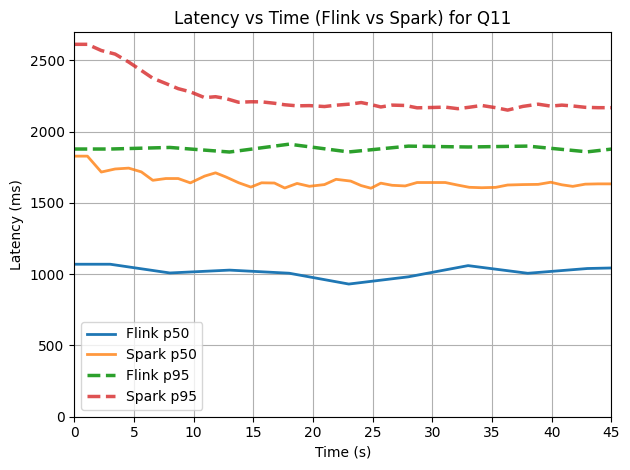

In [538]:
import numpy as np
# --------------------------------------------------
# 5. Plot 1: Latency trends
# --------------------------------------------------
t_min, t_max = 0, 80

df_flink_filtered = df_flink[
    (df_flink["time_sec"] >= t_min) &
    (df_flink["time_sec"] <= t_max)
]

df_spark_filtered = df_spark[
    (df_spark["time_sec"] >= t_min) &
    (df_spark["time_sec"] <= t_max)
]

df_spark_filtered = df_spark_filtered.dropna(subset=["p50_smooth", "p95_smooth"])

def extend_to_zero(df, time_col, cols):
    first_row = df.iloc[0].copy()
    first_row[time_col] = 0
    return pd.concat([pd.DataFrame([first_row]), df], ignore_index=True)

df_flink_filtered = extend_to_zero(df_flink_filtered, "time_sec", ["p50_ms", "p95_ms"])
df_spark_filtered = extend_to_zero(df_spark_filtered, "time_sec", ["p50_smooth", "p95_smooth"])

###########
'''full_time = pd.DataFrame({
    "time_sec": np.arange(0, 51, 1)
})

# --------------------------------------------------
# 2. Ensure Spark is cleaned
# --------------------------------------------------
df_spark_filtered = df_spark_filtered.dropna(
    subset=["p50_smooth", "p95_smooth"]
).sort_values("time_sec")

# --------------------------------------------------
# 3. Merge Spark onto full timeline
# --------------------------------------------------
df_spark_extended = full_time.merge(
    df_spark_filtered,
    on="time_sec",
    how="left"
).sort_values("time_sec")

# --------------------------------------------------
# 4. Forward-fill missing values
#    (this extends last known latency to 50s)
# --------------------------------------------------
df_spark_extended[["p50_smooth", "p95_smooth"]] = (
    df_spark_extended[["p50_smooth", "p95_smooth"]]
    .ffill()
)

# --------------------------------------------------
# 5. OPTIONAL: fill any leading NaNs (if Spark starts late)
# --------------------------------------------------
df_spark_extended[["p50_smooth", "p95_smooth"]] = (
    df_spark_extended[["p50_smooth", "p95_smooth"]]
    .bfill()
)'''
#################
plt.figure()

# --------------------------------------------------
# P50 (solid lines)
# --------------------------------------------------
plt.plot(
    df_flink_filtered["time_sec"],
    df_flink_filtered["p50_ms"],
    label="Flink p50",
    linestyle="-",
    linewidth=2
)

plt.plot(
    df_spark_filtered["time_sec"],
    df_spark_filtered["p50_smooth"],
    label="Spark p50",
    linestyle="-",
    linewidth=2,
    alpha=0.8
)

# --------------------------------------------------
# P95 (dashed lines)
# --------------------------------------------------
plt.plot(
    df_flink_filtered["time_sec"],
    df_flink_filtered["p95_ms"],
    label="Flink p95",
    linestyle="--",
    linewidth=2.5
)

plt.plot(
    df_spark_filtered["time_sec"],
    df_spark_filtered["p95_smooth"],
    label="Spark p95",
    linestyle="--",
    linewidth=2.5,
    alpha=0.8
)

# --------------------------------------------------
# Styling
# --------------------------------------------------
plt.legend()
plt.title("Latency vs Time (Flink vs Spark) for Q11")
plt.xlabel("Time (s)")
plt.ylabel("Latency (ms)")

plt.xlim(0, 45)
plt.ylim(bottom=0)

plt.grid(True)
plt.tight_layout()

plt.savefig("figures/q11_10k/latency_vs_time_flink_spark.png",
            dpi=300, bbox_inches="tight")

plt.show()


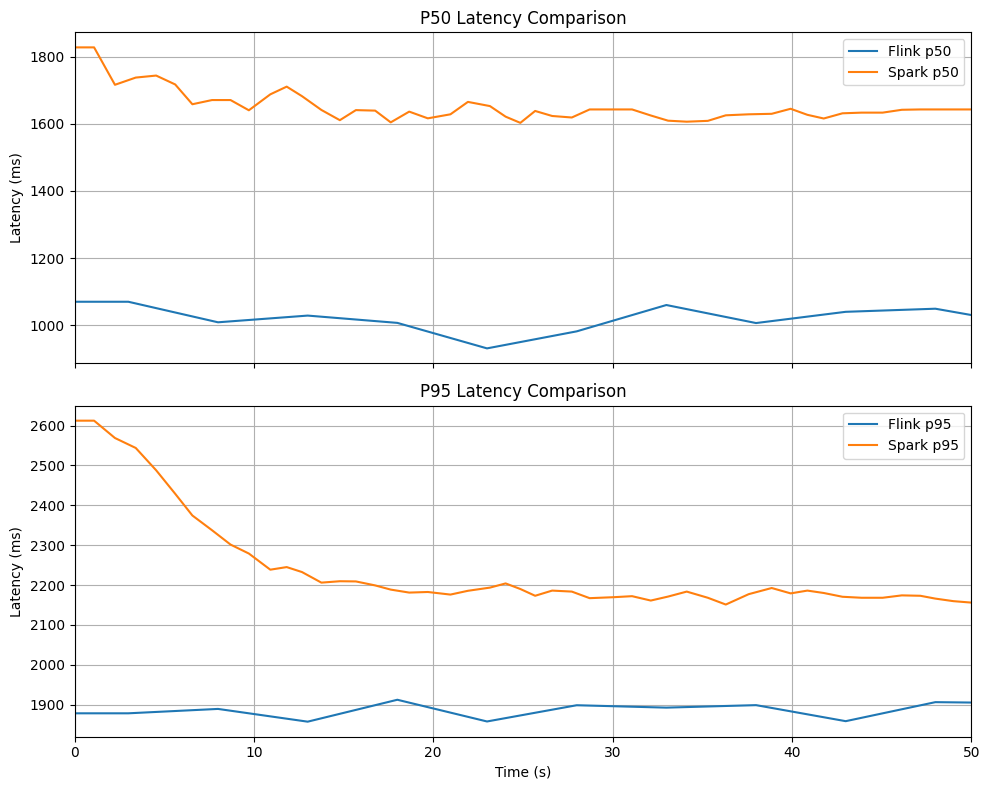

In [539]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --------------------------------------------------
# P50 comparison
# --------------------------------------------------
axes[0].plot(df_flink_filtered["time_sec"], df_flink_filtered["p50_ms"], label="Flink p50")
axes[0].plot(df_spark_filtered["time_sec"], df_spark_filtered["p50_smooth"], label="Spark p50")

axes[0].set_title("P50 Latency Comparison")
axes[0].set_ylabel("Latency (ms)")
axes[0].legend()
axes[0].grid(True)
axes[0].set_xlim(0, 50)   # 🔴 important

# --------------------------------------------------
# P95 comparison
# --------------------------------------------------
axes[1].plot(df_flink_filtered["time_sec"], df_flink_filtered["p95_ms"], label="Flink p95")
axes[1].plot(df_spark_filtered["time_sec"], df_spark_filtered["p95_smooth"], label="Spark p95")

axes[1].set_title("P95 Latency Comparison")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Latency (ms)")
axes[1].legend()
axes[1].grid(True)
axes[1].set_xlim(0, 50)   # 🔴 important

plt.tight_layout()
plt.savefig("figures/q11_10k/latency_vs_time_flink_spark_split.png", dpi=300, bbox_inches="tight")
plt.show()

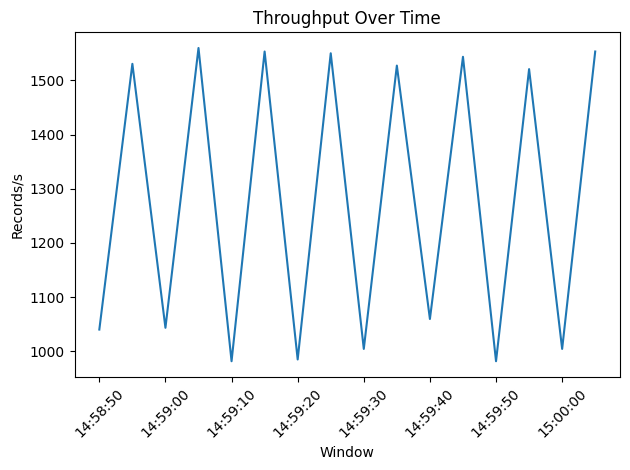

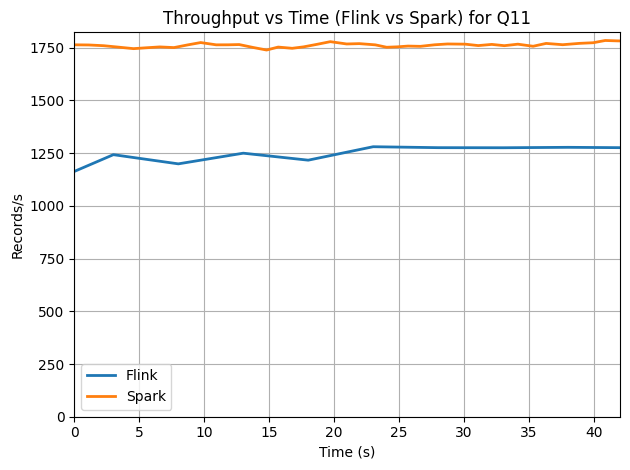

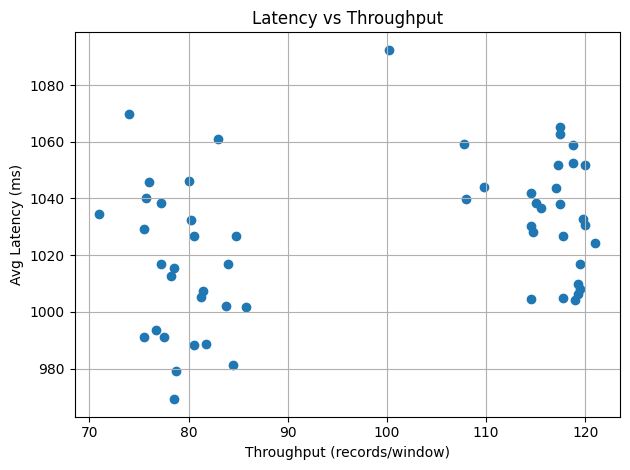

In [540]:

# --------------------------------------------------
# 6. Plot 2: Throughput
# --------------------------------------------------
plt.figure()
plt.plot(df_flink_filtered["window_start"], df_flink_filtered["throughput_per_sec"])
plt.title("Throughput Over Time")
plt.xlabel("Window")
plt.ylabel("Records/s")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ROLLING_WINDOW_throughput = 8  # tweak between 3–7

df_flink_filtered["throughput_smooth"] = (
    df_flink_filtered["throughput_per_sec"]
    .rolling(window=ROLLING_WINDOW_throughput, center=True, min_periods=1)
    .mean()
)
ROLLING_WINDOW_spark = 5
df_spark_filtered["throughput_smooth"] = (
    df_spark_filtered["throughput_rps"]
    .rolling(window=ROLLING_WINDOW_spark, center=True, min_periods=1)
    .mean()
)

plt.figure()

# Smoothed (main line)
plt.plot(
    df_flink_filtered["time_sec"],
    df_flink_filtered["throughput_smooth"],
    label="Flink",
    linewidth=2
)

plt.plot(
    df_spark_filtered["time_sec"],
    df_spark_filtered["throughput_smooth"],
    label="Spark",
    linewidth=2
)

plt.title("Throughput vs Time (Flink vs Spark) for Q11")
plt.xlabel("Time (s)")
plt.ylabel("Records/s")

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.legend()
plt.grid(True)
plt.xlim(0, 42)
plt.tight_layout()

plt.savefig(
    "figures/q11_10k/throughput_vs_time_q11_spark_flink.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# --------------------------------------------------
# 7. Plot 3: Latency vs throughput correlation (optional but useful)
# --------------------------------------------------
plt.figure()
plt.scatter(df_flink["records"], df_flink["avg_latency_ms"])
plt.title("Latency vs Throughput")
plt.xlabel("Throughput (records/window)")
plt.ylabel("Avg Latency (ms)")
plt.tight_layout()
plt.grid(True)
plt.savefig("figures/q11_10k/latency_vs_throughput_q1.png", dpi=300, bbox_inches="tight")
plt.show()